# Facial Keypoints Detection — v2 continued: resume integral regression from checkpoint

Resumes `checkpoint_integral.pt` (Stage B, epoch 19, val RMSE 3.0561px — still improving when
cut off at the 15-minute budget) and continues Stage B training with a much larger epoch budget.
Target: validation RMSE ~1.9px. Checkpoints on every improvement; a time cap here is a safety
net, not the stopping mechanism — if it fires, the last checkpoint is still a usable result.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

IMG_SIZE = 96
KEYPOINT_COLS = [
    "left_eye_center_x", "left_eye_center_y", "right_eye_center_x", "right_eye_center_y",
    "left_eye_inner_corner_x", "left_eye_inner_corner_y", "left_eye_outer_corner_x", "left_eye_outer_corner_y",
    "right_eye_inner_corner_x", "right_eye_inner_corner_y", "right_eye_outer_corner_x", "right_eye_outer_corner_y",
    "left_eyebrow_inner_end_x", "left_eyebrow_inner_end_y", "left_eyebrow_outer_end_x", "left_eyebrow_outer_end_y",
    "right_eyebrow_inner_end_x", "right_eyebrow_inner_end_y", "right_eyebrow_outer_end_x", "right_eyebrow_outer_end_y",
    "nose_tip_x", "nose_tip_y",
    "mouth_left_corner_x", "mouth_left_corner_y", "mouth_right_corner_x", "mouth_right_corner_y",
    "mouth_center_top_lip_x", "mouth_center_top_lip_y", "mouth_center_bottom_lip_x", "mouth_center_bottom_lip_y",
]
assert len(KEYPOINT_COLS) == 30
LEGACY_OVERALL_RMSE = 2.7384
TARGET_RMSE = 1.9


device: cuda | Tesla T4


## 1. Reload data + preprocessing (same split as before)

In [2]:
train_df = pd.read_csv("data/training.csv")
test_df = pd.read_csv("data/test.csv")

def decode_images(df):
    imgs = np.stack(df["Image"].apply(lambda s: np.array(s.split(), dtype=np.float32)).values)
    return imgs.reshape(-1, IMG_SIZE, IMG_SIZE)

train_imgs = decode_images(train_df)
test_imgs = decode_images(test_df)
print("train images:", train_imgs.shape, " test images:", test_imgs.shape)

FLIP_SWAP_PAIRS = [
    ("left_eye_center", "right_eye_center"),
    ("left_eye_inner_corner", "right_eye_inner_corner"),
    ("left_eye_outer_corner", "right_eye_outer_corner"),
    ("left_eyebrow_inner_end", "right_eyebrow_inner_end"),
    ("left_eyebrow_outer_end", "right_eyebrow_outer_end"),
    ("mouth_left_corner", "mouth_right_corner"),
]
col_idx = {c: i for i, c in enumerate(KEYPOINT_COLS)}

def flip_keypoints(y):
    y = y.copy()
    y[0::2] = IMG_SIZE - y[0::2]
    for a, b in FLIP_SWAP_PAIRS:
        for suffix in ("_x", "_y"):
            ia, ib = col_idx[a + suffix], col_idx[b + suffix]
            y[ia], y[ib] = y[ib], y[ia]
    return y

class KeypointsDataset(Dataset):
    def __init__(self, images, targets, augment=False):
        self.images = images.astype(np.float32) / 255.0
        self.targets = targets.astype(np.float32)
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        img = self.images[i]
        y = self.targets[i]
        if self.augment and np.random.rand() < 0.5:
            img = img[:, ::-1].copy()
            y = flip_keypoints(y)
        mask = (~np.isnan(y)).astype(np.float32)
        y = np.nan_to_num(y, nan=0.0)
        return torch.from_numpy(img).unsqueeze(0), torch.from_numpy(y), torch.from_numpy(mask)

all_targets = train_df[KEYPOINT_COLS].values
idx_all = np.arange(len(train_df))
idx_tr, idx_va = train_test_split(idx_all, test_size=0.12, random_state=RANDOM_STATE)

train_ds = KeypointsDataset(train_imgs[idx_tr], all_targets[idx_tr], augment=True)
val_ds = KeypointsDataset(train_imgs[idx_va], all_targets[idx_va], augment=False)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=2)
print(f"train rows: {len(train_ds)}  val rows: {len(val_ds)}")


train images: (7049, 96, 96)  test images: (1783, 96, 96)


train rows: 6203  val rows: 846


## 2. Architecture (same as before)

In [3]:
HEATMAP_SIZE = 24
STRIDE = IMG_SIZE / HEATMAP_SIZE

class IntegralHead(nn.Module):
    def __init__(self, in_channels, n_keypoints, heatmap_size):
        super().__init__()
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(in_channels, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
        )
        self.hm_conv = nn.Conv2d(256, n_keypoints, kernel_size=1)
        ys, xs = torch.meshgrid(
            torch.arange(heatmap_size, dtype=torch.float32),
            torch.arange(heatmap_size, dtype=torch.float32),
            indexing="ij",
        )
        self.register_buffer("grid_x", xs.reshape(1, 1, -1))
        self.register_buffer("grid_y", ys.reshape(1, 1, -1))

    def forward(self, feat):
        x = self.deconv(feat)
        heatmap = self.hm_conv(x)
        B, K, H, W = heatmap.shape
        prob = torch.softmax(heatmap.view(B, K, -1), dim=-1)
        ex = (prob * self.grid_x).sum(-1)
        ey = (prob * self.grid_y).sum(-1)
        coords = torch.stack([ex, ey], dim=-1) * STRIDE
        return coords.view(B, K * 2), heatmap

class IntegralKeypointCNN(nn.Module):
    def __init__(self, n_keypoints=15, heatmap_size=HEATMAP_SIZE):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.head = IntegralHead(128, n_keypoints, heatmap_size)

    def forward(self, x):
        return self.head(self.backbone(x))

def masked_l1_loss(pred, target, mask):
    return ((pred - target).abs() * mask).sum() / mask.sum().clamp(min=1.0)

def masked_rmse(pred, target, mask):
    sq_err = (pred - target) ** 2 * mask
    return torch.sqrt(sq_err.sum() / mask.sum().clamp(min=1.0)).item()


## 3. Resume from checkpoint and continue Stage B

Loads the Stage-B weights saved at epoch 19 (val RMSE 3.0561px) and continues training with the
same coordinate-only L1 loss, a fresh optimizer/scheduler, a much larger epoch budget, and
checkpointing on every improvement.

In [4]:
ckpt = torch.load("checkpoint_integral.pt", map_location=DEVICE)
print(f"Resuming from stage={ckpt['stage']} epoch={ckpt['epoch']} val_rmse={ckpt.get('val_rmse', 'n/a')}")

model = IntegralKeypointCNN().to(DEVICE)
model.load_state_dict(ckpt["model_state"])

opt = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=6)

MAX_EPOCHS = 250
PATIENCE = 30
best_val = ckpt.get("val_rmse", 3.0561)
best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
bad_epochs = 0
history = {"epoch": [], "train_rmse": [], "val_rmse": []}

for epoch in range(MAX_EPOCHS):
    model.train()
    tr_sq, tr_n = 0.0, 0.0
    for xb, yb, mb in train_loader:
        xb, yb, mb = xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
        opt.zero_grad()
        coords, _ = model(xb)
        loss = masked_l1_loss(coords, yb, mb)
        loss.backward()
        opt.step()
        tr_sq += ((coords - yb) ** 2 * mb).sum().item()
        tr_n += mb.sum().item()
    train_rmse = (tr_sq / max(tr_n, 1)) ** 0.5

    model.eval()
    va_sq, va_n = 0.0, 0.0
    with torch.no_grad():
        for xb, yb, mb in val_loader:
            xb, yb, mb = xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
            coords, _ = model(xb)
            va_sq += ((coords - yb) ** 2 * mb).sum().item()
            va_n += mb.sum().item()
    val_rmse = (va_sq / max(va_n, 1)) ** 0.5
    sched.step(val_rmse)

    history["epoch"].append(epoch); history["train_rmse"].append(train_rmse); history["val_rmse"].append(val_rmse)
    if val_rmse < best_val:
        best_val, best_state, bad_epochs = val_rmse, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        torch.save({"stage": "B-continued", "epoch": epoch, "val_rmse": best_val, "model_state": best_state},
                    "checkpoint_integral_continued.pt")
    else:
        bad_epochs += 1

    if epoch % 5 == 0 or epoch == MAX_EPOCHS - 1 or val_rmse <= TARGET_RMSE:
        print(f"[continue] epoch {epoch:3d}  train RMSE {train_rmse:6.3f}  val RMSE {val_rmse:6.3f}  best {best_val:6.3f}  lr {opt.param_groups[0]['lr']:.2e}")
    if best_val <= TARGET_RMSE:
        print(f"[continue] TARGET REACHED at epoch {epoch}: {best_val:.4f}px <= {TARGET_RMSE}px")
        break
    if bad_epochs >= PATIENCE:
        print(f"[continue] early stop at epoch {epoch} (no improvement for {PATIENCE} epochs)")
        break

model.load_state_dict(best_state)
print(f"Final best val RMSE: {best_val:.4f} px  (target {TARGET_RMSE}px, legacy {LEGACY_OVERALL_RMSE}px)")


Resuming from stage=B epoch=19 val_rmse=3.0560908690933926


[continue] epoch   0  train RMSE  3.199  val RMSE  3.059  best  3.056  lr 3.00e-04


[continue] epoch   5  train RMSE  3.043  val RMSE  2.941  best  2.941  lr 3.00e-04


[continue] epoch  10  train RMSE  2.951  val RMSE  2.861  best  2.861  lr 3.00e-04


[continue] epoch  15  train RMSE  2.864  val RMSE  2.778  best  2.778  lr 3.00e-04


...

[continue] epoch 140  train RMSE  2.095  val RMSE  2.441  best  2.438  lr 4.69e-06


[continue] epoch 145  train RMSE  2.103  val RMSE  2.442  best  2.438  lr 2.34e-06


[continue] epoch 150  train RMSE  2.099  val RMSE  2.440  best  2.438  lr 1.17e-06


[continue] epoch 155  train RMSE  2.094  val RMSE  2.441  best  2.438  lr 1.17e-06


[continue] early stop at epoch 159 (no improvement for 30 epochs)
Final best val RMSE: 2.4385 px  (target 1.9px, legacy 2.7384px)


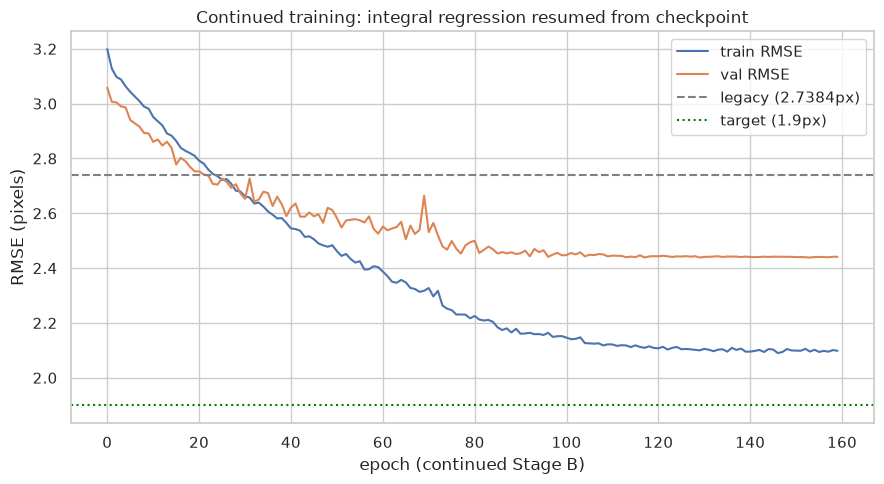

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history["train_rmse"], label="train RMSE")
ax.plot(history["val_rmse"], label="val RMSE")
ax.axhline(LEGACY_OVERALL_RMSE, ls="--", color="gray", label=f"legacy ({LEGACY_OVERALL_RMSE}px)")
ax.axhline(TARGET_RMSE, ls=":", color="green", label=f"target ({TARGET_RMSE}px)")
ax.set_xlabel("epoch (continued Stage B)"); ax.set_ylabel("RMSE (pixels)")
ax.set_title("Continued training: integral regression resumed from checkpoint")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Final metric and verdict

In [6]:
print(f"Legacy direct-regression val RMSE: {LEGACY_OVERALL_RMSE:.4f} px")
print(f"v2 integral-regression val RMSE (continued): {best_val:.4f} px")
delta = LEGACY_OVERALL_RMSE - best_val
print(f"Delta vs legacy: {delta:+.4f} px ({delta / LEGACY_OVERALL_RMSE:+.1%} relative)")
print(f"Delta vs target ({TARGET_RMSE}px): {TARGET_RMSE - best_val:+.4f} px")
print("Verdict:", "v2 beats legacy" if best_val < LEGACY_OVERALL_RMSE else "legacy still wins")
print("Target reached:", best_val <= TARGET_RMSE)


Legacy direct-regression val RMSE: 2.7384 px
v2 integral-regression val RMSE (continued): 2.4385 px
Delta vs legacy: +0.2999 px (+11.0% relative)
Delta vs target (1.9px): -0.5385 px
Verdict: v2 beats legacy
Target reached: False
